# Continuous Identity Trust — Live Demo

**Shifting from gatekeepers to real-time behavioural inference.**

Point-in-time login is a front door: once you're in, you're trusted for the whole
session. That's exactly the gap mid-session account-takeover (ATO), session
hijacking and replay bots walk through.

This notebook is a runnable prototype of the **continuous** alternative described in
the pitch. It demonstrates the full loop end-to-end, with zero infrastructure:

1. **Telemetry** — behavioural-biometric signals (mouse kinematics + keystroke timing).
2. **Features** — Polars micro-batch aggregation into interpretable behavioural physics.
3. **Inference** — an ML model turns each window into a continuous risk score.
4. **Feedback loop** — a smoothed *risk state* trips **step-up authentication** the
   instant a logged-in human "turns into" a bot.

> Telemetry here is **synthetic** so the demo is self-contained. In production the
> raw stream comes from the Wasm client agent over WebSockets; everything downstream
> of ingestion is the real prototype.

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

import cit
from cit import (
    generate_session, generate_dataset, build_feature_table,
    train_model, replay_session, FEATURE_COLS,
)

plt.rcParams.update({
    "figure.facecolor": "#11161b", "axes.facecolor": "#11161b",
    "axes.edgecolor": "#444", "text.color": "#e6e6e6",
    "axes.labelcolor": "#e6e6e6", "xtick.color": "#aaa", "ytick.color": "#aaa",
    "axes.titlecolor": "#00ffcc", "grid.color": "#222", "font.size": 11,
})
ACCENT, ALERT, HUMAN = "#00ffcc", "#ff3366", "#4aa3ff"
np.random.seed(0)
print("cit prototype loaded — Polars", pl.__version__)

cit prototype loaded — Polars 1.42.0


## 1 · What the agent sees: behavioural telemetry

The client agent samples pointer position and keystroke timing at high frequency.
A **human** produces curved, jittery paths with variable cadence and irregular typing
rhythm. A **bot / replay script** moves in near-straight lines at a metronomic rate and
types with uncanny uniformity. We never look at *what* the user does — only the *physics*
of how they do it.

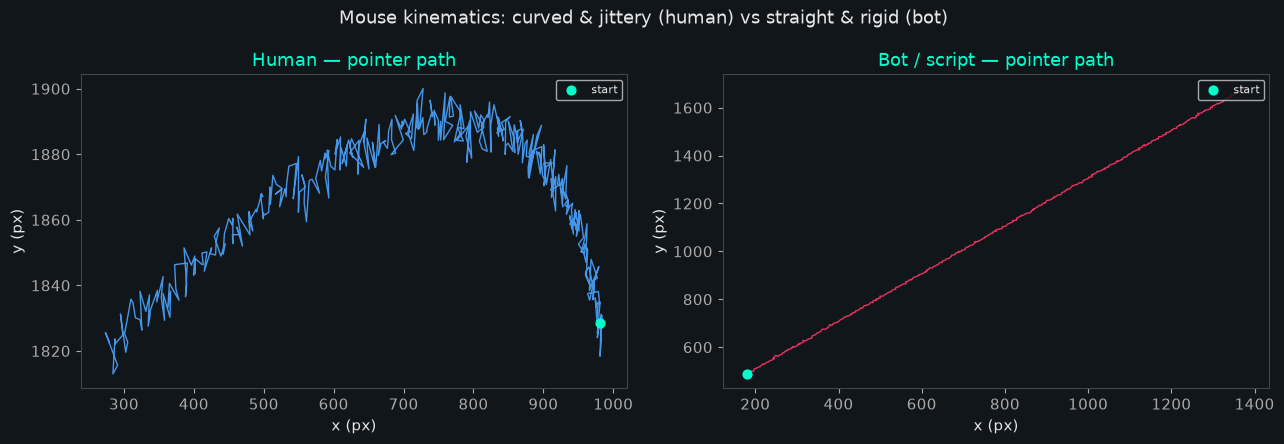

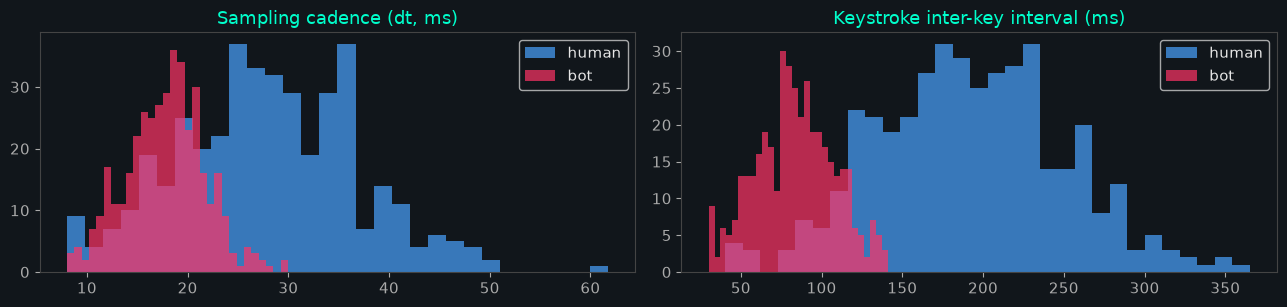

In [2]:
human = generate_session("demo_human", "human", n_events=400, seed=1)
bot   = generate_session("demo_bot",   "bot",   n_events=400, seed=2)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for a, sess, name, c in [(ax[0], human, "Human", HUMAN), (ax[1], bot, "Bot / script", ALERT)]:
    a.plot(sess["x"], sess["y"], c=c, lw=1.0, alpha=0.9)
    a.scatter(sess["x"][0], sess["y"][0], c=ACCENT, s=40, zorder=5, label="start")
    a.set_title(f"{name} — pointer path"); a.set_xlabel("x (px)"); a.set_ylabel("y (px)")
    a.legend(loc="upper right", fontsize=8)
fig.suptitle("Mouse kinematics: curved & jittery (human) vs straight & rigid (bot)", color="#e6e6e6")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(13, 3.2))
ax[0].hist(human["dt_ms"], bins=30, color=HUMAN, alpha=0.7, label="human")
ax[0].hist(bot["dt_ms"], bins=30, color=ALERT, alpha=0.7, label="bot")
ax[0].set_title("Sampling cadence (dt, ms)"); ax[0].legend()
ax[1].hist(human["key_interval_ms"], bins=30, color=HUMAN, alpha=0.7, label="human")
ax[1].hist(bot["key_interval_ms"], bins=30, color=ALERT, alpha=0.7, label="bot")
ax[1].set_title("Keystroke inter-key interval (ms)"); ax[1].legend()
plt.tight_layout(); plt.show()

## 2 · Polars feature engineering

Each session is sliced into overlapping windows; every window is reduced to seven
interpretable behavioural-physics features. This is the real-time micro-batch
aggregation tier — in the live system Polars does this on the streaming buffer.

In [3]:
dataset = generate_dataset(n_human=120, n_bot=120, n_events=400, seed=7)
feat = build_feature_table(dataset, window=50, stride=25)
print(f"{dataset.height:,} raw events  ->  {feat.height:,} feature windows "
      f"across {feat['session_id'].n_unique()} sessions")
feat.select(FEATURE_COLS + ["label"]).head(5)

96,000 raw events  ->  3,600 feature windows across 240 sessions


speed_mean,speed_std,accel_std,path_efficiency,angle_std,dt_std,key_interval_std,label
f64,f64,f64,f64,f64,f64,f64,i64
0.317076,0.237935,0.325307,0.339105,2.059667,8.545516,59.206692,0
0.280948,0.171831,0.259216,0.348493,2.060501,7.123254,57.771566,0
0.263659,0.186534,0.287808,0.39492,1.954736,8.283951,45.034071,0
0.254481,0.186931,0.290501,0.34768,1.970346,9.650531,40.942021,0
0.245846,0.162212,0.252757,0.283989,2.040484,9.457586,54.902485,0


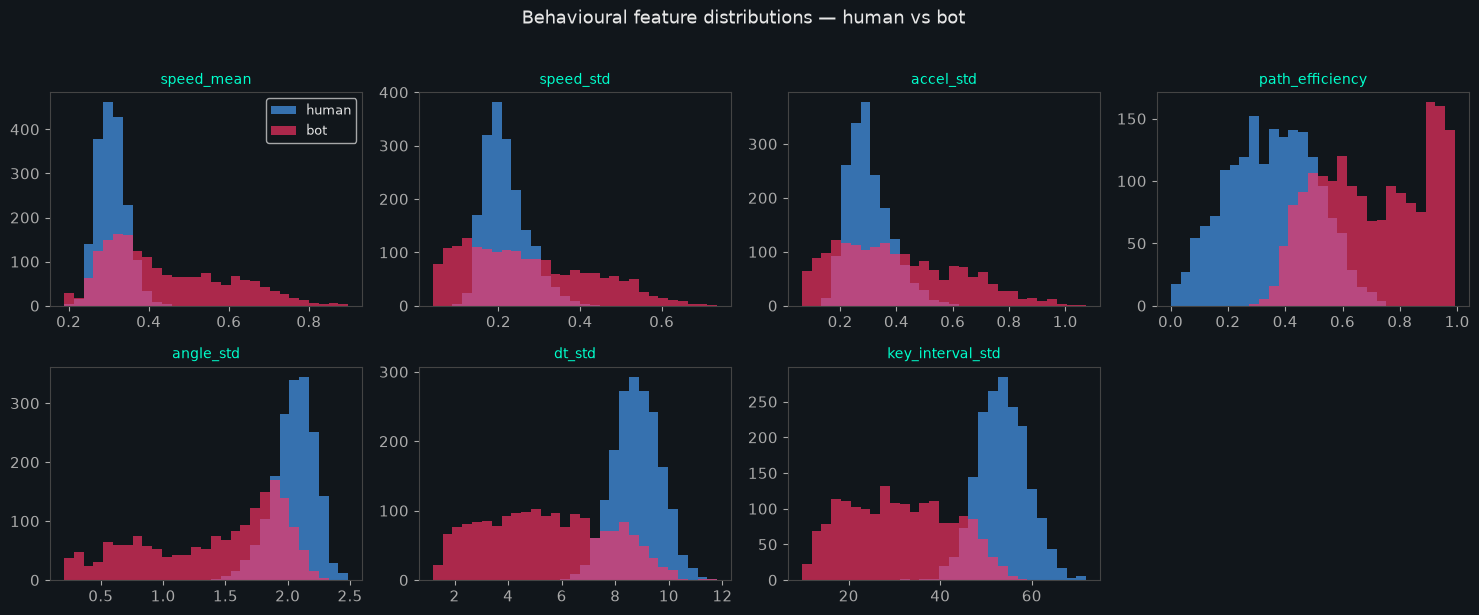

In [4]:
# How cleanly each feature separates the two populations
hum = feat.filter(pl.col("label") == 0)
bt  = feat.filter(pl.col("label") == 1)
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, col in zip(axes.ravel(), FEATURE_COLS):
    lo = float(min(hum[col].min(), bt[col].min()))
    hi = float(max(hum[col].max(), bt[col].max()))
    bins = np.linspace(lo, hi, 30)
    ax.hist(hum[col], bins=bins, color=HUMAN, alpha=0.65, label="human")
    ax.hist(bt[col],  bins=bins, color=ALERT, alpha=0.65, label="bot")
    ax.set_title(col, fontsize=10)
axes.ravel()[-1].axis("off")
axes.ravel()[0].legend(fontsize=9)
fig.suptitle("Behavioural feature distributions — human vs bot", color="#e6e6e6", y=1.02)
plt.tight_layout(); plt.show()

## 3 · Training the risk model

A gradient-boosted classifier learns the human/bot boundary. We split **by session**
(not by window) so windows from one session never leak across the train/test divide —
the honest way to measure generalisation.

> On this synthetic corpus the behavioural-physics features are strongly separable,
> so accuracy is near-ceiling — that's a property of clean generated data, not a claim
> of perfection. In production the hard part isn't this boundary, it's **distribution
> drift and adversarial mimicry**, which is exactly why the engine leans on a smoothed
> *continuous* risk state (next section) rather than any single classifier verdict.

In [5]:
sids = feat["session_id"].unique().to_list()
rng = np.random.default_rng(0); rng.shuffle(sids)
cut = int(len(sids) * 0.3)
test_ids, train_ids = set(sids[:cut]), set(sids[cut:])
train = feat.filter(pl.col("session_id").is_in(list(train_ids)))
test  = feat.filter(pl.col("session_id").is_in(list(test_ids)))

model = train_model(train)
proba = model.score_windows(test)
y_true = test["label"].to_numpy()
auc = roc_auc_score(y_true, proba)
print(f"Held-out sessions: {len(test_ids)} | windows: {test.height}")
print(f"Window-level ROC-AUC: {auc:.4f}\n")
print(classification_report(y_true, (proba >= 0.5).astype(int),
                            target_names=["human", "bot"]))

Held-out sessions: 72 | windows: 1080
Window-level ROC-AUC: 1.0000

              precision    recall  f1-score   support

       human       1.00      1.00      1.00       555
         bot       1.00      1.00      1.00       525

    accuracy                           1.00      1080
   macro avg       1.00      1.00      1.00      1080
weighted avg       1.00      1.00      1.00      1080



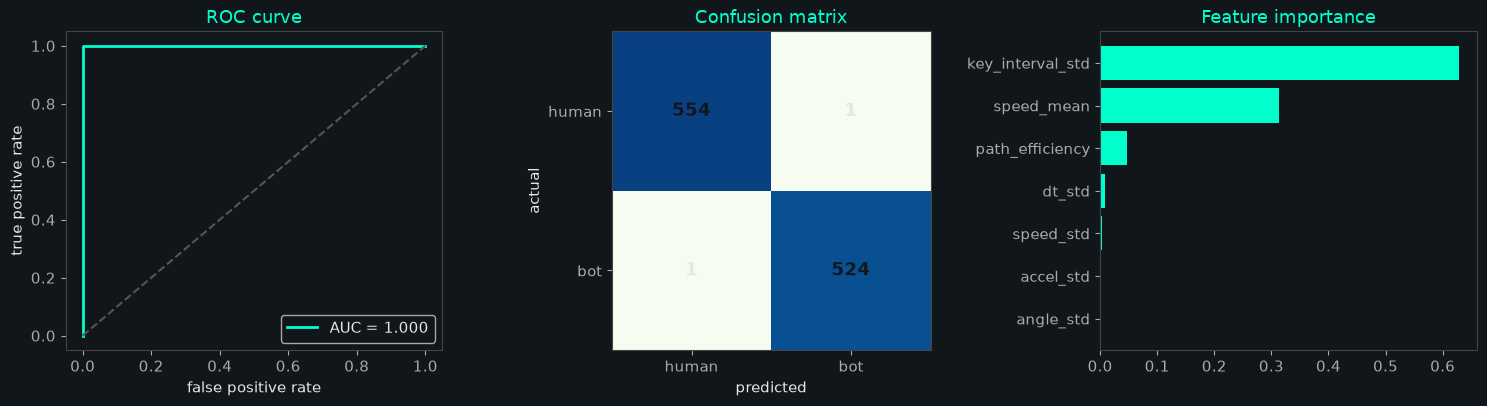

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
# ROC
fpr, tpr, _ = roc_curve(y_true, proba)
ax[0].plot(fpr, tpr, c=ACCENT, lw=2, label=f"AUC = {auc:.3f}")
ax[0].plot([0, 1], [0, 1], "--", c="#555")
ax[0].set_title("ROC curve"); ax[0].set_xlabel("false positive rate")
ax[0].set_ylabel("true positive rate"); ax[0].legend(loc="lower right")
# Confusion
cm = confusion_matrix(y_true, (proba >= 0.5).astype(int))
ax[1].imshow(cm, cmap="GnBu")
ax[1].set_xticks([0, 1], ["human", "bot"]); ax[1].set_yticks([0, 1], ["human", "bot"])
ax[1].set_xlabel("predicted"); ax[1].set_ylabel("actual"); ax[1].set_title("Confusion matrix")
for (i, j), v in np.ndenumerate(cm):
    ax[1].text(j, i, str(v), ha="center", va="center",
               color="#11161b" if v > cm.max()/2 else "#e6e6e6", fontsize=13, weight="bold")
# Importances
imp = model.clf.feature_importances_
order = np.argsort(imp)
ax[2].barh(np.array(FEATURE_COLS)[order], imp[order], color=ACCENT)
ax[2].set_title("Feature importance")
plt.tight_layout(); plt.show()

## 4 · The money shot: catching a mid-session takeover

This is the scenario static auth cannot see. A session **starts as a legitimate human**,
sails through login — and **halfway through, control is hijacked** by a script (stolen
session, remote-access tooling, replay).

We stream the session through a stateful `SessionMonitor` window by window. Each window
yields an *instantaneous* risk; an exponential moving average smooths it into the
**continuous risk state** (the value that lives in Redis). The moment that smoothed state
crosses the threshold, the engine fires **step-up authentication** — automatically,
mid-session, with no friction until the instant risk is real.

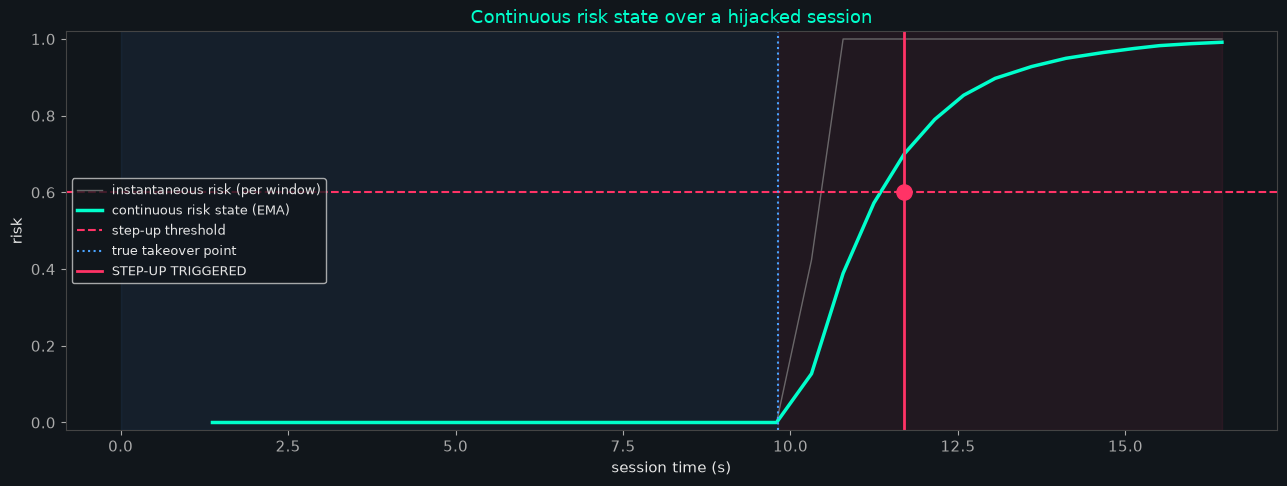

Takeover occurred at  t =    9.8s
Step-up triggered at  t =   11.7s
Detection latency:        1.9s after the session turned malicious


In [7]:
ato = generate_session("ato_demo", "account_takeover", n_events=700,
                       takeover_at=0.5, seed=42)
mon = replay_session(model, ato, window=50, stride=25,
                     ema_alpha=0.3, step_up_threshold=0.6)
h = mon.to_frame()
takeover_t = float(ato["t_ms"][int(700 * 0.5)])

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(h["t_end_ms"]/1000, h["instant_risk"], c="#888", lw=1, alpha=0.7,
        label="instantaneous risk (per window)")
ax.plot(h["t_end_ms"]/1000, h["risk_state"], c=ACCENT, lw=2.5,
        label="continuous risk state (EMA)")
ax.axhline(0.6, ls="--", c=ALERT, lw=1.5, label="step-up threshold")
ax.axvspan(0, takeover_t/1000, color=HUMAN, alpha=0.07)
ax.axvspan(takeover_t/1000, h["t_end_ms"].max()/1000, color=ALERT, alpha=0.07)
ax.axvline(takeover_t/1000, c=HUMAN, ls=":", lw=1.5, label="true takeover point")
if mon.step_up_t_ms:
    ax.axvline(mon.step_up_t_ms/1000, c=ALERT, lw=2, label="STEP-UP TRIGGERED")
    ax.scatter([mon.step_up_t_ms/1000], [0.6], c=ALERT, s=120, zorder=6)
ax.set_xlabel("session time (s)"); ax.set_ylabel("risk")
ax.set_ylim(-0.02, 1.02); ax.set_title("Continuous risk state over a hijacked session")
ax.legend(loc="center left", fontsize=9)
plt.tight_layout(); plt.show()

if mon.step_up_t_ms:
    lag = (mon.step_up_t_ms - takeover_t) / 1000
    print(f"Takeover occurred at  t = {takeover_t/1000:6.1f}s")
    print(f"Step-up triggered at  t = {mon.step_up_t_ms/1000:6.1f}s")
    print(f"Detection latency:        {lag:.1f}s after the session turned malicious")

## 5 · Fleet view: thousands of concurrent risk states

In production Redis holds one live risk score per session. Here we replay a mix of
genuine humans, outright bots, and ATO sessions through the engine and overlay their
trajectories — genuine sessions stay quiet, hostile ones climb and trip the line.
**Friction lands only where risk is real.**

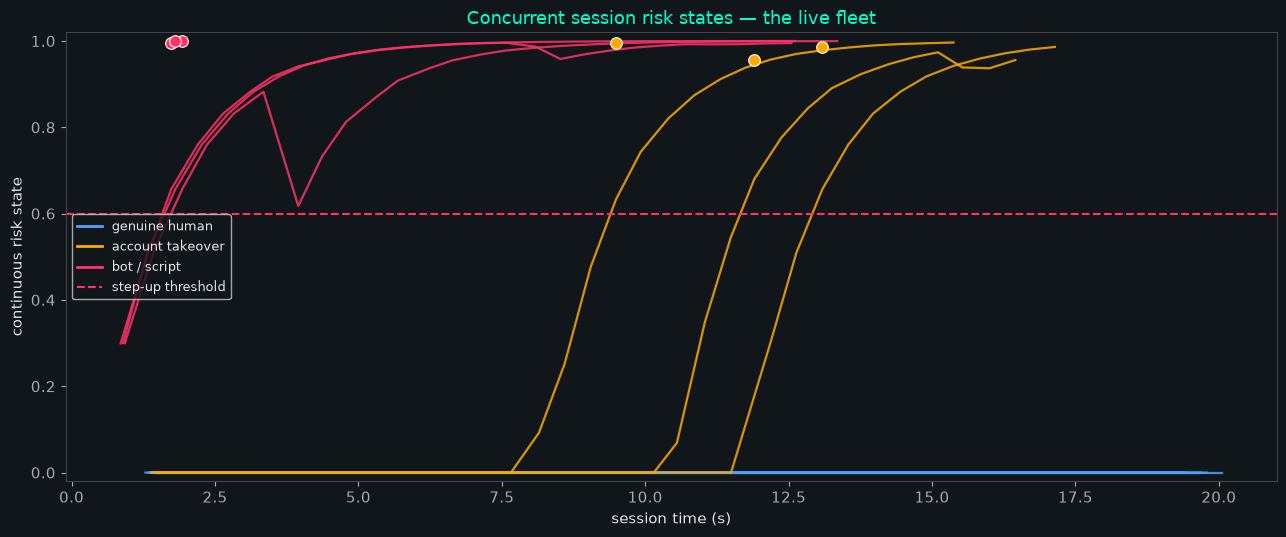

6 of 12 sessions escalated to step-up; all 6 genuine humans stayed frictionless.


In [8]:
scenarios = (
    [("human", f"user-{i}", None) for i in range(6)] +
    [("bot", f"bot-{i}", None) for i in range(3)] +
    [("account_takeover", f"ato-{i}", 0.4 + 0.1*i) for i in range(3)]
)
fig, ax = plt.subplots(figsize=(13, 5.5))
flagged = 0
for kind, name, ta in scenarios:
    kw = dict(takeover_at=ta) if ta else {}
    s = generate_session(name, kind, n_events=700, seed=hash(name) % 9999, **kw)
    m = replay_session(model, s, ema_alpha=0.3, step_up_threshold=0.6)
    hh = m.to_frame()
    color = {"human": HUMAN, "bot": ALERT, "account_takeover": "#ffaa00"}[kind]
    ax.plot(hh["t_end_ms"]/1000, hh["risk_state"], c=color, lw=1.6, alpha=0.85)
    if m.stepped_up:
        flagged += 1
        ax.scatter([m.step_up_t_ms/1000], [m.risk], c=color, s=70, zorder=5,
                   edgecolors="white", linewidths=0.8)
ax.axhline(0.6, ls="--", c=ALERT, lw=1.5)
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], color=HUMAN, lw=2, label="genuine human"),
    Line2D([0],[0], color="#ffaa00", lw=2, label="account takeover"),
    Line2D([0],[0], color=ALERT, lw=2, label="bot / script"),
    Line2D([0],[0], color=ALERT, ls="--", label="step-up threshold"),
], loc="center left", fontsize=9)
ax.set_xlabel("session time (s)"); ax.set_ylabel("continuous risk state")
ax.set_ylim(-0.02, 1.02); ax.set_title("Concurrent session risk states — the live fleet")
plt.tight_layout(); plt.show()
print(f"{flagged} of {len(scenarios)} sessions escalated to step-up; "
      f"all {sum(1 for k,_,_ in scenarios if k=='human')} genuine humans stayed frictionless.")

## From prototype to production

What's real here today: the **feature engineering, the model, the continuous-risk
state machine, and the step-up feedback loop** — the entire decision core.

To productionise, swap the synthetic generator for live signals and scale the runtime:

| Tier | Prototype (this notebook) | Production (per the pitch) |
|------|---------------------------|----------------------------|
| Telemetry | synthetic generator | Wasm (Rust/C++) client agent |
| Ingestion | in-process Polars | async Python + WebSockets + Polars |
| Inference | scikit-learn GBM | PyTorch / XGBoost, Numba-compiled features |
| Session state | `SessionMonitor` object | Redis in-memory risk state |
| Action | `stepped_up` flag | API call forcing step-up auth |

**The thesis, demonstrated:** trust isn't a one-time gate — it's a continuously
inferred state, and it can be defended in real time without taxing the user.